# ATP Tennis Tournament Predictor

**Features:** Elo (global + surface-specific), ATP ranking, H2H win rate, rolling surface win rate, recent form, age  
**Model:** XGBoost binary classifier trained on symmetrised pairwise match data  
**Validation:** Walk-forward backtesting  
**Live use:** `PlayerStateTracker` + `TournamentSimulator`

---
### Pipeline
```
Raw data (JeffSackmann) → Clean → Feature engineering → Train → Backtest → Predict / Simulate
```

In [1]:
import sys, os
# Make src importable from the notebook
sys.path.insert(0, os.path.abspath('.'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')
PALETTE = sns.color_palette('Set2')
print('Libraries loaded.')

Libraries loaded.


---
## 1  Load & Clean Data

In [2]:
from src.data.fetch import fetch_matches, fetch_players
from src.data.process import clean_matches

# Adjust years as needed — first run downloads ~25 CSV files (~30 MB total)
START_YEAR = 2000
END_YEAR   = 2024

raw = fetch_matches(start_year=START_YEAR, end_year=END_YEAR)
players = fetch_players()
matches = clean_matches(raw)
print(f"\nClean dataset: {len(matches):,} matches")
print(f"Date range   : {matches.tourney_date.min().date()} → {matches.tourney_date.max().date()}")
print(f"Surfaces     : {matches.surface.value_counts().to_dict()}")
print(f"Complete matches: {matches.is_complete.sum():,}  ({matches.is_complete.mean():.1%})")

Loaded 74,906 matches (2000–2024)

Clean dataset: 74,906 matches
Date range   : 2000-01-03 → 2024-12-18
Surfaces     : {'Hard': 40871, 'Clay': 24244, 'Grass': 7699, 'Carpet': 2039, 'Unknown': 53}
Complete matches: 72,285  (96.5%)


In [3]:
# Quick peek at the data
matches[['tourney_date','tourney_name','surface','round',
         'winner_name','winner_rank','loser_name','loser_rank','score']].head(10)

,tourney_date,tourney_name,surface,round,winner_name,winner_rank,loser_name,loser_rank,score
0,2000-01-03,Adelaide,Hard,R32,Thomas Enqvist,4,Arnaud Clement,56,6-3 6-4
1,2000-01-03,Adelaide,Hard,R32,Roger Federer,64,Jens Knippschild,91,6-1 6-4
2,2000-01-03,Adelaide,Hard,R32,Jan Michael Gambill,58,Wayne Arthurs,105,3-6 7-6(5) 6-4
3,2000-01-03,Adelaide,Hard,R32,Sebastien Grosjean,27,Andrew Ilie,54,6-2 6-1
4,2000-01-03,Adelaide,Hard,R32,Magnus Norman,15,Scott Draper,154,6-4 6-4
5,2000-01-03,Adelaide,Hard,R32,Richard Fromberg,78,Todd Woodbridge,197,7-6(5) 5-7 6-4
6,2000-01-03,Adelaide,Hard,R32,James Sekulov,144,Gianluca Pozzi,94,6-4 2-6 6-2
7,2000-01-03,Adelaide,Hard,R32,Alberto Martin,57,Vincent Spadea,20,6-2 6-2
8,2000-01-03,Adelaide,Hard,R32,Lleyton Hewitt,25,Mark Woodforde,130,6-3 2-6 6-1
9,2000-01-03,Adelaide,Hard,R32,Dejan Petrovic,205,Stephane Huet,127,3-6 6-3 6-3


---
## 2  Exploratory Data Analysis

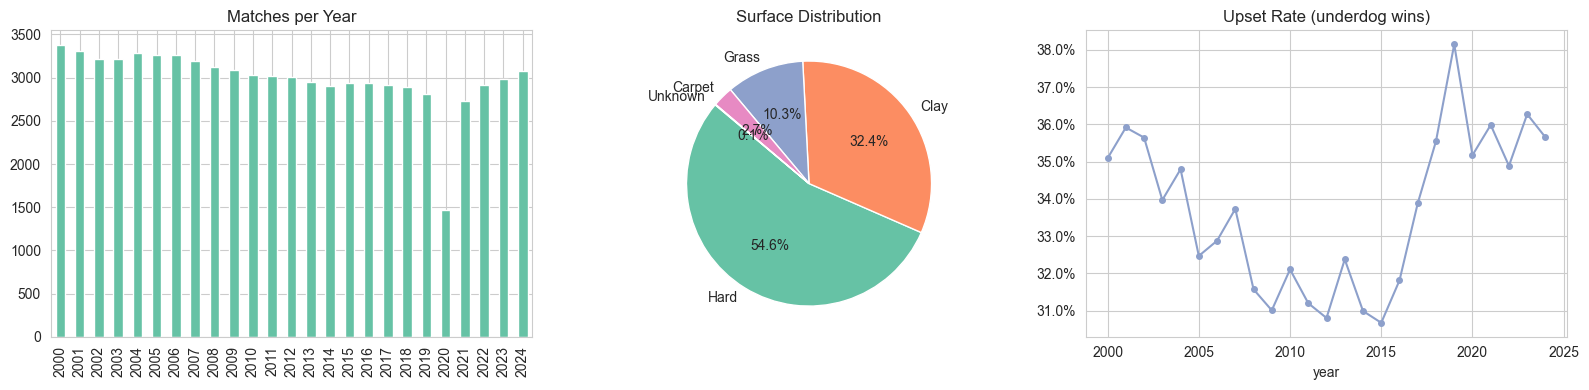

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Matches per year
matches.groupby('year').size().plot(kind='bar', ax=axes[0], color=PALETTE[0], edgecolor='white')
axes[0].set_title('Matches per Year'); axes[0].set_xlabel('')

# Surface distribution
surf_counts = matches['surface'].value_counts()
axes[1].pie(surf_counts, labels=surf_counts.index, autopct='%1.1f%%',
            colors=PALETTE, startangle=140)
axes[1].set_title('Surface Distribution')

# Upset rate (lower-ranked player wins) by year
m = matches[matches.is_complete]
upset = m[m.winner_rank > m.loser_rank].groupby('year').size() / m.groupby('year').size()
upset.plot(ax=axes[2], color=PALETTE[2], marker='o', ms=4)
axes[2].set_title('Upset Rate (underdog wins)'); axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

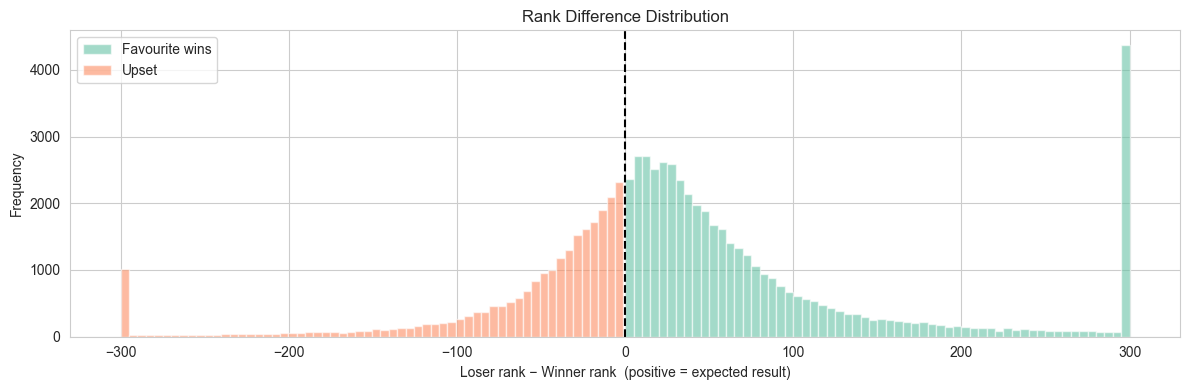

In [5]:
# Rank difference distribution for upsets vs expected results
m = matches[matches.is_complete].copy()
m['rank_diff'] = m['loser_rank'] - m['winner_rank']   # positive = favourite won
m['upset'] = m['winner_rank'] > m['loser_rank']

fig, ax = plt.subplots(figsize=(12, 4))
m[~m['upset']]['rank_diff'].clip(-300, 300).plot.hist(
    bins=60, alpha=0.6, color=PALETTE[0], label='Favourite wins', ax=ax)
m[m['upset']]['rank_diff'].clip(-300, 300).plot.hist(
    bins=60, alpha=0.6, color=PALETTE[1], label='Upset', ax=ax)
ax.axvline(0, color='black', lw=1.5, ls='--')
ax.set_title('Rank Difference Distribution')
ax.set_xlabel('Loser rank − Winner rank  (positive = expected result)')
ax.legend(); plt.tight_layout(); plt.show()

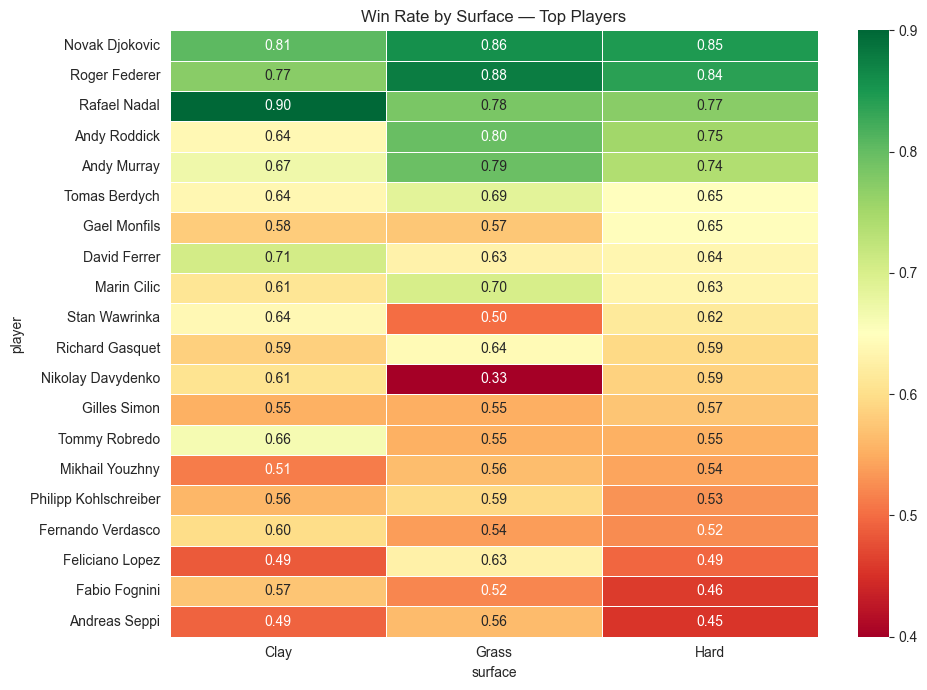

In [6]:
# Win rate by surface for top 20 most active players
top_players = pd.concat([
    matches[['winner_name']].rename(columns={'winner_name':'name'}),
    matches[['loser_name']].rename(columns={'loser_name':'name'})
]).value_counts('name').head(20).index

rows = []
for name in top_players:
    wins = matches[matches.winner_name == name]
    losses = matches[matches.loser_name == name]
    for surf in ['Hard','Clay','Grass']:
        w = (wins.surface == surf).sum()
        total = w + (losses.surface == surf).sum()
        if total >= 20:
            rows.append({'player': name, 'surface': surf, 'win_rate': w/total, 'n': total})

wr_df = pd.DataFrame(rows).pivot(index='player', columns='surface', values='win_rate')

plt.figure(figsize=(10, 7))
sns.heatmap(wr_df.sort_values('Hard', ascending=False),
            annot=True, fmt='.2f', cmap='RdYlGn', vmin=0.4, vmax=0.9,
            linewidths=0.5)
plt.title('Win Rate by Surface — Top Players'); plt.tight_layout(); plt.show()

---
## 3  Feature Engineering

All features are computed **strictly before** each match to avoid look-ahead bias.

| Feature | Description |
|---|---|
| `elo_diff` | Global Elo difference (p1 − p2) |
| `surface_elo_diff` | Surface-specific Elo difference |
| `rank_diff` | ATP rank difference |
| `rank_points_diff` | ATP ranking points difference |
| `p1_h2h_winrate` | p1's historical H2H win rate vs p2 |
| `h2h_total` | Total H2H matches played |
| `surf_winrate_diff` | Surface win-rate diff (rolling 365 days) |
| `form_diff` | Recent form diff (last 20 matches) |
| `age_diff` | Age difference in years |
| `p1_surf_n` / `p2_surf_n` | # surface matches in window |

In [7]:
from src.features.builder import build_features, symmetrize

# This may take 2–5 minutes on first run; result is cached to data/processed/features.pkl
feat_matches = build_features(matches, use_cache=True)

Loading cached features from data/processed/features.pkl


In [8]:
# Symmetrise for training: each match becomes 2 rows (winner-as-p1 and loser-as-p1)
sym = symmetrize(feat_matches)
print(f"Symmetrised dataset: {len(sym):,} rows  |  target balance: {sym.target.mean():.2f}")
sym.head(3)

Symmetrised dataset: 149,812 rows  |  target balance: 0.50


,p1_id,p2_id,p1_name,p2_name,p1_elo,p2_elo,p1_surface_elo,p2_surface_elo,p1_rank,p2_rank,p1_rank_points,p2_rank_points,p1_surf_winrate,p2_surf_winrate,p1_form,p2_form,p1_h2h_winrate,p1_surf_n,p2_surf_n,h2h_total,age_diff,target,tourney_date,year,surface,match_idx,is_complete,elo_diff,surface_elo_diff,rank_diff,rank_points_diff,surf_winrate_diff,form_diff
0,102358,103096,Thomas Enqvist,Arnaud Clement,1500.000,1500.000,1500.000,1500.000,4,56,2606.000,805.000,0.500,0.500,0.500,0.500,0.500,0,0,0,3.700,1,2000-01-03,2000,Hard,0,True,0.000,0.000,-52,1801.000,0.000,0.000
1,103819,102533,Roger Federer,Jens Knippschild,1500.000,1500.000,1500.000,1500.000,64,91,749.000,525.000,0.500,0.500,0.500,0.500,0.500,0,0,0,-6.500,1,2000-01-03,2000,Hard,1,True,0.000,0.000,-27,224.000,0.000,0.000
2,102998,101885,Jan Michael Gambill,Wayne Arthurs,1500.000,1500.000,1500.000,1500.000,58,105,803.000,449.000,0.500,0.500,0.500,0.500,0.500,0,0,0,-6.200,1,2000-01-03,2000,Hard,2,True,0.000,0.000,-47,354.000,0.000,0.000


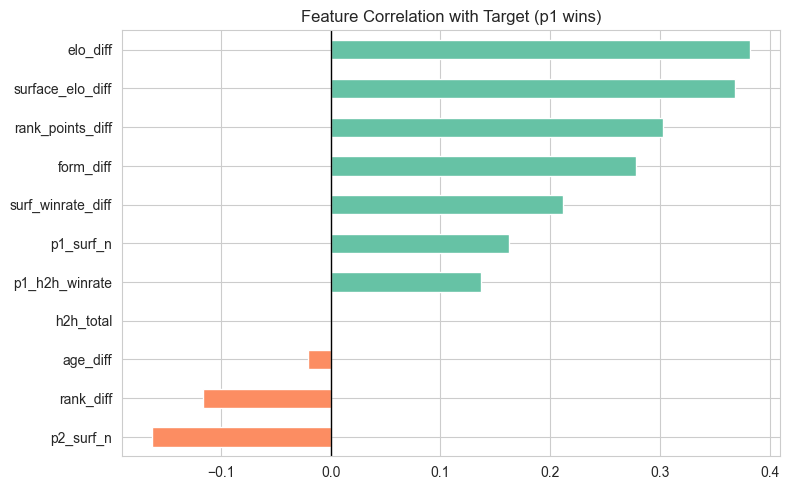

In [9]:
from src.features.builder import MODEL_FEATURES

# Feature correlation with target
corr = sym[MODEL_FEATURES + ['target']].corr()['target'].drop('target').sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
corr.plot(kind='barh', ax=ax,
          color=[PALETTE[0] if v > 0 else PALETTE[1] for v in corr])
ax.axvline(0, color='black', lw=1)
ax.set_title('Feature Correlation with Target (p1 wins)')
plt.tight_layout(); plt.show()

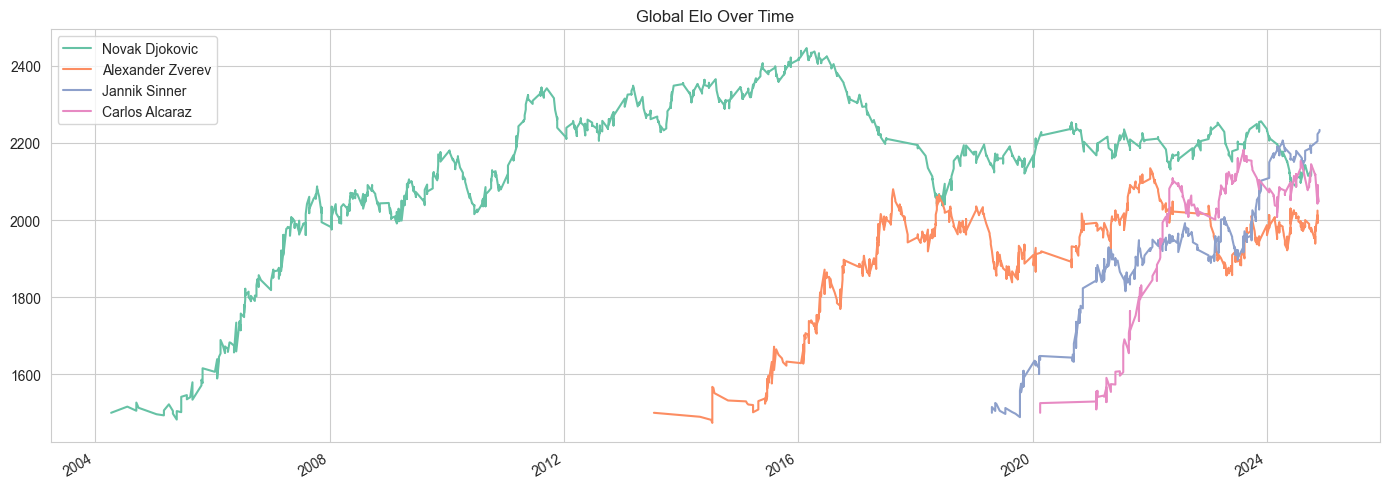

In [10]:
# Elo distribution over time for a few famous players
SHOW_PLAYERS = ['Novak Djokovic', 'Alexander Zverev', 'Jannik Sinner', 'Carlos Alcaraz']

fig, ax = plt.subplots(figsize=(14, 5))
for pname, color in zip(SHOW_PLAYERS, PALETTE):
    pdata = feat_matches[feat_matches.winner_name == pname][['tourney_date','winner_elo']]\
        .rename(columns={'winner_elo':'elo'})
    pdata2 = feat_matches[feat_matches.loser_name == pname][['tourney_date','loser_elo']]\
        .rename(columns={'loser_elo':'elo'})
    pd.concat([pdata, pdata2]).sort_values('tourney_date').plot(
        x='tourney_date', y='elo', ax=ax, label=pname, color=color)
ax.set_title('Global Elo Over Time'); ax.set_xlabel('')
ax.legend(); plt.tight_layout(); plt.show()

---
## 4  Model Training

In [11]:
from src.models.train import train_model, evaluate, feature_importance_df

# Temporal split: train on 2000–2021, validate on 2022–2024
train_df = sym[sym.year <= 2021]
val_df   = sym[sym.year >= 2022]
print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}")

model = train_model(train_df, model_path='models/xgb_atp.joblib')

Train: 131,854  |  Val: 17,958
Model saved to models/xgb_atp.joblib  (127,188 training samples)


In [12]:
train_metrics = evaluate(model, train_df)
val_metrics   = evaluate(model, val_df)

metrics_df = pd.DataFrame([train_metrics, val_metrics], index=['Train','Val'])
print(metrics_df.to_string())

            n  accuracy  log_loss  brier_score
Train  131854     0.686     0.582        0.200
Val     17958     0.658     0.608        0.211


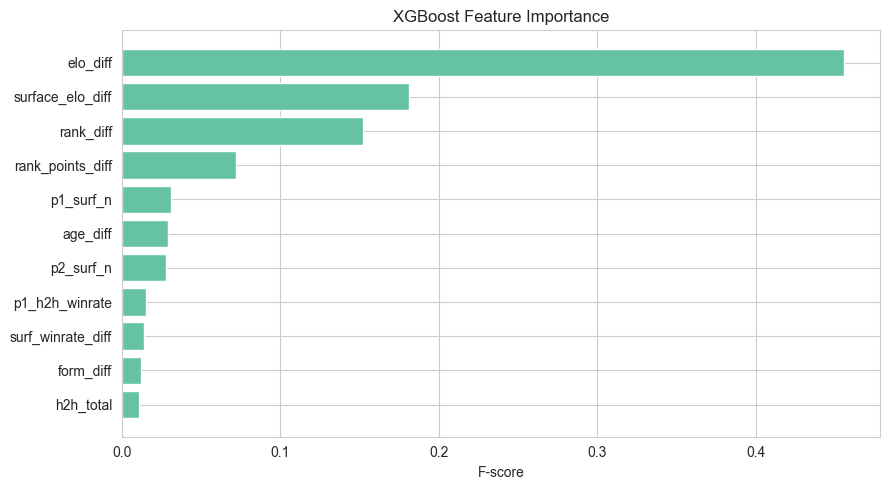

In [13]:
imp = feature_importance_df(model)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp.feature, imp.importance, color=PALETTE[0], edgecolor='white')
ax.invert_yaxis()
ax.set_title('XGBoost Feature Importance')
ax.set_xlabel('F-score')
plt.tight_layout(); plt.show()

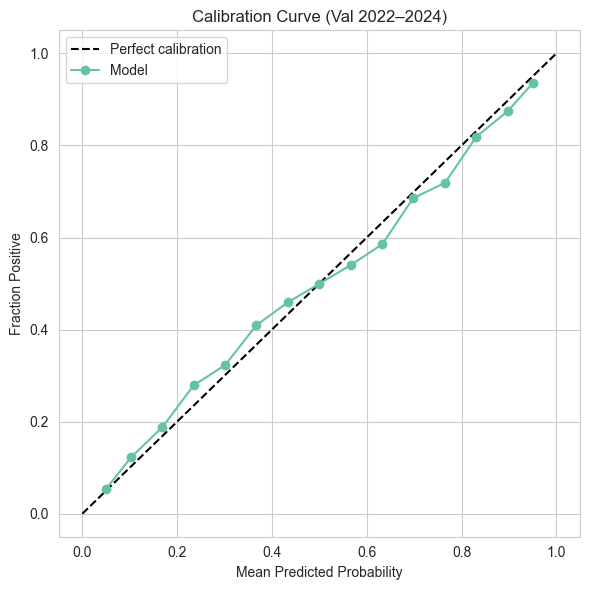

In [14]:
# Calibration curve — how well do predicted probabilities match actual win rates?
from sklearn.calibration import calibration_curve

vdf = val_df.dropna(subset=MODEL_FEATURES)
probs = model.predict_proba(vdf[MODEL_FEATURES])[:, 1]

frac_pos, mean_pred = calibration_curve(vdf['target'], probs, n_bins=15)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(mean_pred, frac_pos, 'o-', color=PALETTE[0], label='Model')
ax.set_xlabel('Mean Predicted Probability'); ax.set_ylabel('Fraction Positive')
ax.set_title('Calibration Curve (Val 2022–2024)')
ax.legend(); plt.tight_layout(); plt.show()

---
## 5  Walk-Forward Backtesting

In [15]:
from src.models.backtest import walk_forward_backtest, baseline_elo_only

print("Running walk-forward backtest (2018–2024)...")
bt = walk_forward_backtest(sym, test_start_year=2018, train_window_years=10)
elo_bt = baseline_elo_only(sym, test_start_year=2018)
print("\n", bt.to_string(index=False))

Running walk-forward backtest (2018–2024)...
  2018  n= 5626  acc=0.667  logloss=0.610  brier=0.211
  2019  n= 5452  acc=0.658  logloss=0.610  brier=0.212
  2020  n= 2860  acc=0.659  logloss=0.597  brier=0.206
  2021  n= 5302  acc=0.652  logloss=0.608  brier=0.211
  2022  n= 5658  acc=0.675  logloss=0.591  brier=0.203
  2023  n= 5778  acc=0.654  logloss=0.613  brier=0.213
  2024  n= 5946  acc=0.657  logloss=0.603  brier=0.209

  year  n_matches  accuracy  log_loss  brier_score
 2018       5626     0.667     0.610        0.211
 2019       5452     0.658     0.610        0.212
 2020       2860     0.659     0.597        0.206
 2021       5302     0.652     0.608        0.211
 2022       5658     0.675     0.591        0.203
 2023       5778     0.654     0.613        0.213
 2024       5946     0.657     0.603        0.209


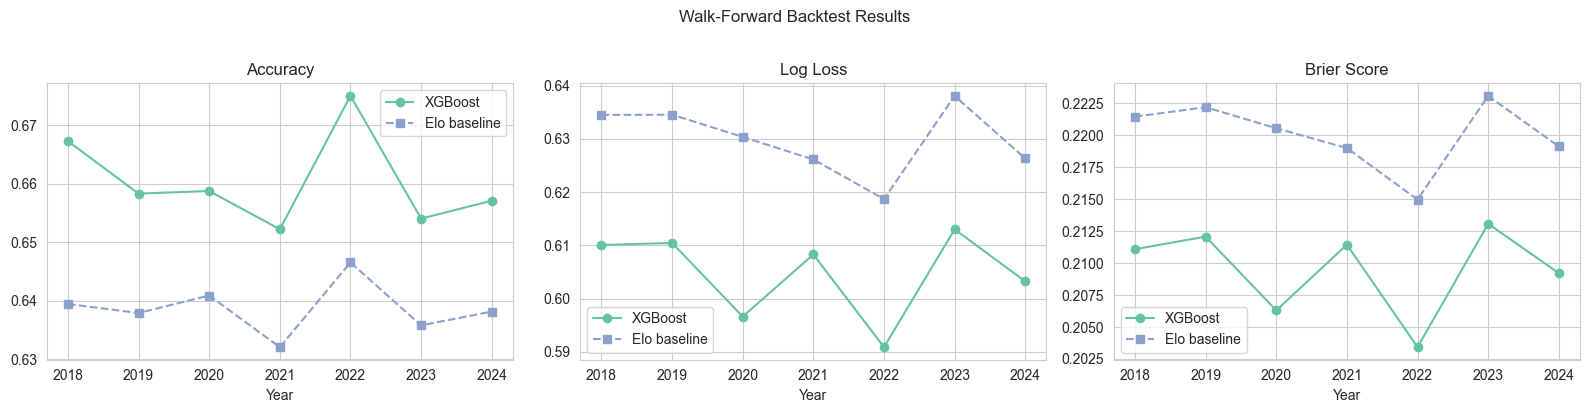

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title in zip(axes, ['accuracy','log_loss','brier_score'],
                           ['Accuracy','Log Loss','Brier Score']):
    bt.plot(x='year', y=col, ax=ax, color=PALETTE[0], marker='o', label='XGBoost')
    elo_bt.plot(x='year', y=col, ax=ax, color=PALETTE[2], marker='s',
                linestyle='--', label='Elo baseline')
    ax.set_title(title); ax.set_xlabel('Year'); ax.legend()

plt.suptitle('Walk-Forward Backtest Results', y=1.02)
plt.tight_layout(); plt.show()

---
## 6  Live Player State

Process all historical matches to build each player's current state.

In [17]:
from src.models.predict import PlayerStateTracker, MatchPredictor

tracker = PlayerStateTracker(form_window=20, surface_window_days=365)
tracker.process_all(matches)   # builds live state for every player
print(f"Tracking {len(tracker.global_elo):,} players")

Building state: 100%|██████████| 74906/74906 [00:01<00:00, 41658.70it/s]

Tracking 2,640 players


In [18]:
# Inspect current state of a player
pid = tracker.find_player_id('Jannik Sinner')
state = tracker.get_player_state(pid, 'Clay')
pd.Series(state)

id                     206173
name            Jannik Sinner
elo                  2235.589
surface_elo          1838.943
rank                        1
rank_points         11830.000
surf_winrate            0.786
surf_n                     14
form                    0.950
form_n                     20
age                    23.200
dtype: object

In [19]:
# Top 15 players by current global Elo
top_elo = sorted(tracker.global_elo.items(), key=lambda x: x[1], reverse=True)[:15]
top_elo_df = pd.DataFrame([
    {'name': tracker.name.get(pid, str(pid)),
     'elo': round(elo, 1),
     'rank': tracker.rank.get(pid, 9999)}
    for pid, elo in top_elo
])
print(top_elo_df.to_string(index=False))

                 name      elo  rank
        Jannik Sinner 2235.600     1
       Novak Djokovic 2122.500     4
       Carlos Alcaraz 2052.600     3
      Robin Soderling 2044.000     5
        Roger Federer 2026.100     8
     Alexander Zverev 2004.900     2
         Taylor Fritz 1972.800     4
         Nick Kyrgios 1938.800    25
Juan Martin del Potro 1937.600   753
      Daniil Medvedev 1928.600     4
          Jack Draper 1906.100    15
      Grigor Dimitrov 1895.000     9
       Alex De Minaur 1891.100     9
         Rafael Nadal 1880.900   154
          Holger Rune 1876.200    13


---
## 7  Single Match Prediction

In [20]:
predictor = MatchPredictor(model_path='models/xgb_atp.joblib')

def predict_match(name1: str, name2: str, surface: str = 'Hard'):
    """Predict win probability for name1 vs name2 on a given surface."""
    id1 = tracker.find_player_id(name1)
    id2 = tracker.find_player_id(name2)
    if id1 is None:
        print(f"Player not found: {name1}"); return
    if id2 is None:
        print(f"Player not found: {name2}"); return

    n1 = tracker.name[id1]
    n2 = tracker.name[id2]
    prob, info = predictor.predict_from_tracker(tracker, id1, id2, surface)

    h2h_w, h2h_l, _ = tracker.get_h2h(id1, id2)
    print(f"{'='*55}")
    print(f"  {n1:25s}  vs  {n2}")
    print(f"  Surface : {surface}")
    print(f"  H2H     : {h2h_w}–{h2h_l} in favour of {n1}")
    print(f"  Elo     : {info['p1']['elo']:.0f}  vs  {info['p2']['elo']:.0f}")
    print(f"  Surf Elo: {info['p1']['surface_elo']:.0f}  vs  {info['p2']['surface_elo']:.0f}")
    print(f"  Rank    : #{info['p1']['rank']}  vs  #{info['p2']['rank']}")
    print(f"{'='*55}")
    print(f"  P({n1} wins) = {prob:.1%}")
    print(f"  P({n2} wins) = {1-prob:.1%}")
    print(f"{'='*55}")
    return prob

In [21]:
# Example predictions — edit names as you like
predict_match('Jannik Sinner', 'Carlos Alcaraz', surface='Clay')

  Jannik Sinner              vs  Carlos Alcaraz
  Surface : Clay
  H2H     : 4–6 in favour of Jannik Sinner
  Elo     : 2236  vs  2053
  Surf Elo: 1839  vs  1988
  Rank    : #1  vs  #3
  P(Jannik Sinner wins) = 47.4%
  P(Carlos Alcaraz wins) = 52.6%


0.4742176830768585

In [25]:
predict_match('Jakub Mensik', 'Luciano Darderi', surface='Clay')

  Jakub Mensik               vs  Luciano Darderi
  Surface : Clay
  H2H     : 1–0 in favour of Jakub Mensik
  Elo     : 1703  vs  1549
  Surf Elo: 1564  vs  1625
  Rank    : #48  vs  #43
  P(Jakub Mensik wins) = 54.5%
  P(Luciano Darderi wins) = 45.5%


0.5447554588317871

In [26]:
predict_match('Joao Fonseca', 'Arthur Rinderknech', surface = 'Clay')

  Joao Fonseca               vs  Arthur Rinderknech
  Surface : Clay
  H2H     : 0–0 in favour of Joao Fonseca
  Elo     : 1641  vs  1655
  Surf Elo: 1520  vs  1544
  Rank    : #145  vs  #60
  P(Joao Fonseca wins) = 53.7%
  P(Arthur Rinderknech wins) = 46.3%


0.5370920896530151

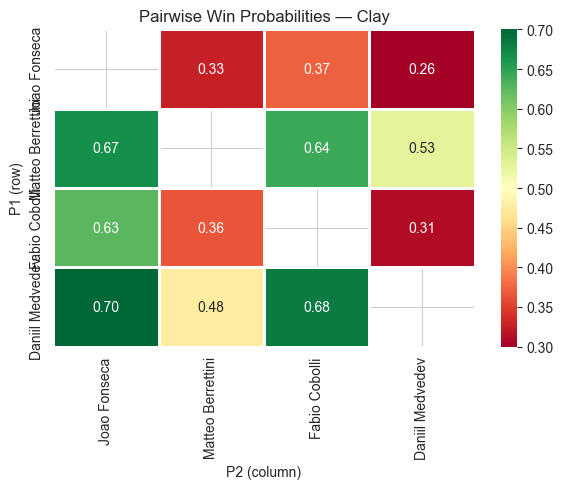

In [27]:
# Predict all pairwise matchups in a list of players
PLAYERS = ['Joao Fonseca', 'Matteo Berrettini', 'Fabio Cobolli', 'Daniil Medvedev']
SURFACE = 'Clay'

ids = {n: tracker.find_player_id(n) for n in PLAYERS}

matrix = pd.DataFrame(index=PLAYERS, columns=PLAYERS, dtype=float)
for n1 in PLAYERS:
    for n2 in PLAYERS:
        if n1 == n2:
            matrix.loc[n1, n2] = np.nan
        else:
            id1, id2 = ids[n1], ids[n2]
            if id1 and id2:
                p, _ = predictor.predict_from_tracker(tracker, id1, id2, SURFACE)
                matrix.loc[n1, n2] = round(p, 3)

plt.figure(figsize=(6, 5))
sns.heatmap(matrix.astype(float), annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=0.3, vmax=0.7, linewidths=1)
plt.title(f'Pairwise Win Probabilities — {SURFACE}')
plt.ylabel('P1 (row)'); plt.xlabel('P2 (column)')
plt.tight_layout(); plt.show()

---
## 8  Tournament Simulation

Monte Carlo bracket simulation.  
Provide players **in bracket order** (1 vs 2, 3 vs 4, …).  
List length must be a power of 2 (8, 16, 32, 64, 128).

In [ ]:
from typing import Any


from src.models.predict import TournamentSimulator

simulator = TournamentSimulator(predictor, tracker)

# --- Edit this list to match an actual draw ---
# Players must be in bracket order: [Q1_R1, Q1_R2, Q2_R1, Q2_R2, ...]
DRAW_NAMES = [
    'Luciano Darderi',   'Jakub Mensik',
    'Valentin Vacherot',     'Arthur Rinderknech',
    'Matteo Berrettini',  ' Felix Auger-Aliassime',
    'Lorenzo Musetti',  'Daniil Medvedev',
]
SURFACE = 'Clay'
N_SIM = 50_000

draw_ids = []
for name in DRAW_NAMES:
    pid = tracker.find_player_id(name)
    if pid is None:
        print(f"WARNING: '{name}' not found — check spelling")
    draw_ids.append(pid)

# Filter out Nones
valid = [(n, i) for n, i in zip[tuple[str, Any]](DRAW_NAMES, draw_ids) if i is not None]
DRAW_NAMES_OK = [v[0] for v in valid]
draw_ids_ok   = [v[1] for v in valid]

# Pad to next power of 2 with a dummy if needed (unlikely for hand-picked draws)
print(f"Draw size: {len(draw_ids_ok)} players")

Draw size: 8 players


In [29]:
results = simulator.simulate(draw_ids_ok, surface=SURFACE, n_sim=N_SIM, seed=0)
print(results[['name','win_prob','elo','surface_elo','rank','form','surf_winrate']].to_string(index=False))

                 name  win_prob      elo  surface_elo  rank  form  surf_winrate
    Matteo Berrettini     0.219 1838.700     1898.400    35 0.650         0.938
      Daniil Medvedev     0.216 1928.600     1741.900     4 0.550         0.688
      Lorenzo Musetti     0.178 1798.500     1787.300    17 0.550         0.600
Felix Auger Aliassime     0.132 1759.700     1755.100    19 0.550         0.692
         Jakub Mensik     0.121 1702.600     1563.800    48 0.500         0.600
      Luciano Darderi     0.072 1549.200     1625.000    43 0.250         0.656
   Arthur Rinderknech     0.053 1654.900     1544.200    60 0.500         0.400
    Valentin Vacherot     0.010 1478.500     1464.500   116 0.300         0.400


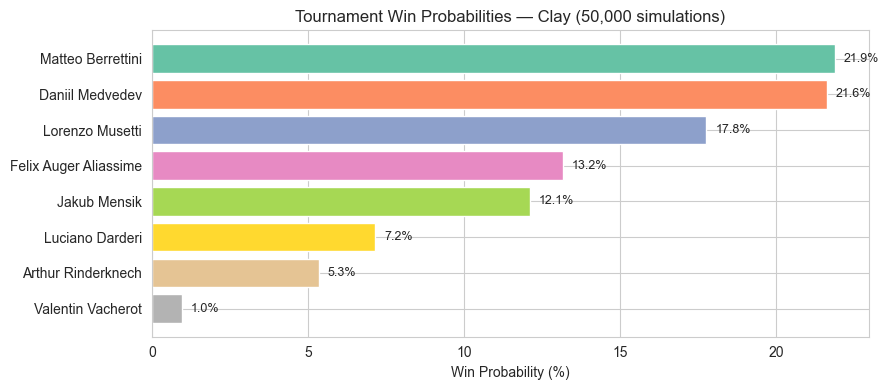

In [30]:
# Visualise win probabilities
fig, ax = plt.subplots(figsize=(9, 4))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(results))]
ax.barh(results['name'], results['win_prob'] * 100, color=colors, edgecolor='white')
ax.set_xlabel('Win Probability (%)')
ax.set_title(f'Tournament Win Probabilities — {SURFACE} ({N_SIM:,} simulations)')
ax.invert_yaxis()
for i, (_, row) in enumerate(results.iterrows()):
    ax.text(row.win_prob * 100 + 0.3, i, f"{row.win_prob:.1%}", va='center', fontsize=9)
plt.tight_layout(); plt.show()

---
## 9  Historical Tournament Replay

Pick any past tournament and compare simulated vs actual results.

In [38]:
# Choose a tournament to analyse
TOURNEY = 'Monte Carlo'
YEAR    = 2024

tourn = feat_matches[
    (feat_matches.tourney_name.str.contains(TOURNEY, case=False)) &
    (feat_matches.year == YEAR)
].sort_values('round_num')

print(f"{TOURNEY} {YEAR} — {len(tourn)} matches")
print(tourn[['round','winner_name','loser_name','winner_elo','loser_elo','elo_diff']].to_string(index=False))

Monte Carlo 2024 — 55 matches
round             winner_name                  loser_name  winner_elo  loser_elo  elo_diff
  R64         Roman Safiullin                 Jaume Munar    1696.476   1571.626   124.849
  R64             Arthur Fils            Yannick Hanfmann    1652.281   1632.697    19.584
  R64         Lorenzo Musetti                Taylor Fritz    1648.756   1833.955  -185.199
  R64          Alex De Minaur               Stan Wawrinka    1950.794   1616.629   334.165
  R64       Tallon Griekspoor             Dominik Koepfer    1784.549   1664.920   119.629
  R64          Alexei Popyrin             Corentin Moutet    1704.938   1554.100   150.838
  R64   Felix Auger Aliassime                  Luca Nardi    1727.093   1517.002   210.091
  R64           Zhizhen Zhang                Marcos Giron    1633.539   1674.621   -41.082
  R64             Ugo Humbert              Federico Coria    1885.173   1596.040   289.134
  R64          Hubert Hurkacz                 Jack Draper   

In [39]:
# Accuracy of model on this specific tournament (using pre-match features)
if len(tourn) > 0:
    sym_tourn = symmetrize(tourn)
    sym_tourn = sym_tourn[sym_tourn.target == 1]  # only the correct orientation
    sym_tourn = sym_tourn.dropna(subset=MODEL_FEATURES)

    if len(sym_tourn) > 0:
        probs = model.predict_proba(sym_tourn[MODEL_FEATURES])[:, 1]
        correct = (probs >= 0.5).sum()
        print(f"{TOURNEY} {YEAR}: model predicted {correct}/{len(sym_tourn)} matches correctly "
              f"({correct/len(sym_tourn):.1%})")

        sym_tourn = sym_tourn.copy()
        sym_tourn['pred_prob'] = probs
        sym_tourn[['p1_name','p2_name','pred_prob']].assign(
            correct=probs >= 0.5).to_string(index=False)

        print(sym_tourn[['p1_name','p2_name','pred_prob']].assign(
            correct=(probs >= 0.5)).to_string(index=False))

Monte Carlo 2024: model predicted 39/55 matches correctly (70.9%)
                p1_name                     p2_name  pred_prob  correct
        Roman Safiullin                 Jaume Munar      0.491    False
            Arthur Fils            Yannick Hanfmann      0.642     True
        Lorenzo Musetti                Taylor Fritz      0.451    False
         Alex De Minaur               Stan Wawrinka      0.766     True
      Tallon Griekspoor             Dominik Koepfer      0.601     True
         Alexei Popyrin             Corentin Moutet      0.687     True
  Felix Auger Aliassime                  Luca Nardi      0.749     True
          Zhizhen Zhang                Marcos Giron      0.510     True
            Ugo Humbert              Federico Coria      0.529     True
         Hubert Hurkacz                 Jack Draper      0.703     True
  Roberto Bautista Agut         Facundo Diaz Acosta      0.425    False
       Alejandro Tabilo        Christopher Oconnell      0.529     Tru

---
## 10  Custom / Live Prediction

If you have updated ranking / Elo data, you can manually override a player's state.

In [40]:
# Example: override a player's current rank / Elo for a hypothetical scenario
import copy

custom_tracker = copy.deepcopy(tracker)

# e.g. manually update Djokovic's rank after injury lay-off
djok_id = custom_tracker.find_player_id('Novak Djokovic')
if djok_id:
    custom_tracker.rank[djok_id] = 3
    custom_tracker.global_elo[djok_id] = 2150.0

# Now predict using the modified tracker
custom_predictor = MatchPredictor(model_path='models/xgb_atp.joblib')
alc_id = custom_tracker.find_player_id('Carlos Alcaraz')
if djok_id and alc_id:
    prob, info = custom_predictor.predict_from_tracker(custom_tracker, djok_id, alc_id, 'Clay')
    print(f"Custom scenario — Djokovic vs Alcaraz (Clay): {prob:.1%} / {1-prob:.1%}")

Custom scenario — Djokovic vs Alcaraz (Clay): 41.2% / 58.8%
